## Lab # 06: Support Vector Machine (SVM) Classifier

### **Student Information**
- **Name**: Abdul Hayy Khan
- **Roll No**: 24F-AI-051

### Lab Tasks:
1.	Load a dataset for classification (e.g., Parkinson disease, Breast Cancer dataset).

In [13]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [14]:
# load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())
print("\nDataset Shape:", X.shape)

Features:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0 

2.	Apply data preprocessing (handle missing values, encode categorical data).

In [15]:
# checking missing values
print("Total Missing Values:", X.isnull().sum().sum())

Total Missing Values: 0


3.	Split the dataset into training and testing sets.

In [16]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


4.	Apply Grid search to find the optimal parameters

In [18]:
# creating a pipeline with StandardScaler and RandomForestClassifier
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

In [19]:
# parameters to test
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

In [20]:
# performing grid search with cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [21]:
# fitting the grid search to the training data
grid_search.fit(X_train, y_train)

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto'], 'svm__kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [22]:
# display best parameters
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

Best Cross-Validation Accuracy:
0.9780219780219781


5.	Use those parameters to make predictions on the test set.

In [23]:
# evaluating the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


6.	Evaluate performance using accuracy, precision, recall, and F1-score.

In [24]:
# calculating performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


7.	Visualize the Confusion Matrix


Confusion Matrix:
[[41  1]
 [ 1 71]]


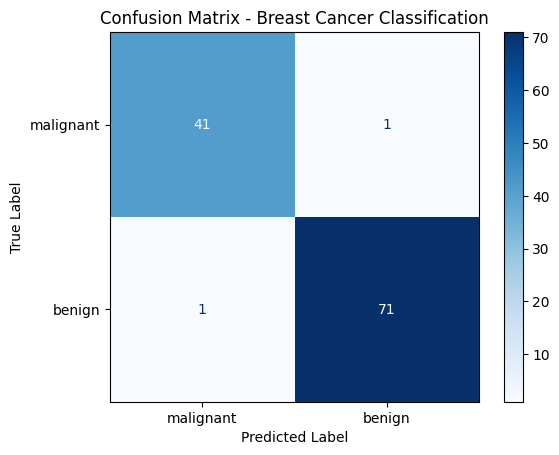

In [25]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Breast Cancer Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()